In [ ]:
# 1. Load Data
# 2. Daily Returns
# 3. CAGR
# 4. Sharpe Ratio
# 5. Sortino Ratio
# 6. Alpha & Beta
# 7. Maximum Drawdown
# 8. Fund Scorecard
# 9. Benchmark Comparison
# 10. Export CSVs

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

nav = pd.read_csv("../data/raw/02_nav_history.csv")
bench = pd.read_csv("../data/raw/10_benchmark_indices.csv")
funds = pd.read_csv("../data/raw/01_fund_master.csv")

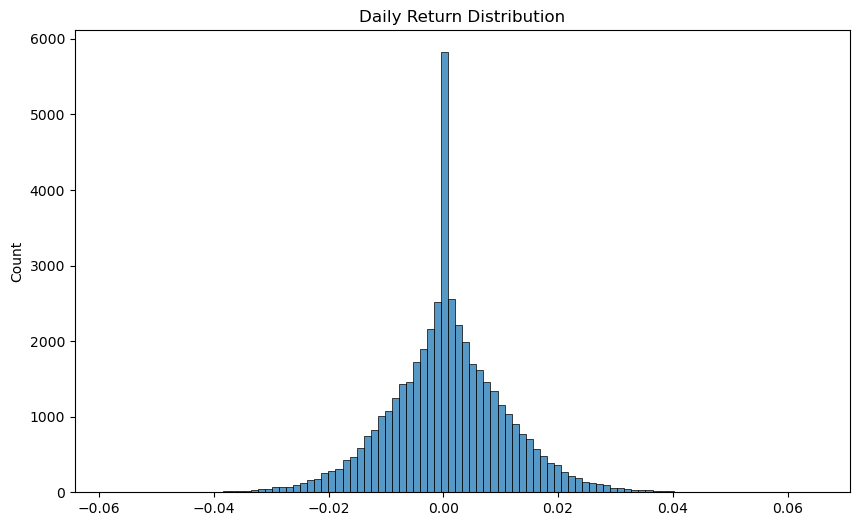

In [4]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code","date"])
nav["daily_return"] = (nav.groupby("amfi_code")["nav"].pct_change())
nav["daily_return"].describe()
plt.figure(figsize=(10,6))
sns.histplot(list(nav["daily_return"].dropna()), bins=100)
plt.title("Daily Return Distribution")
plt.show()

In [ ]:
def calculate_cagr(df):
    start = df.iloc[0]["nav"]
    end = df.iloc[-1]["nav"]
    years = (df.iloc[-1]["date"] - df.iloc[0]["date"]).days / 365.25
    return ((end/start)**(1/years) - 1)
cagr_table = (nav.groupby("amfi_code").apply(calculate_cagr).reset_index())
cagr_table.columns = ["amfi_code", "cagr"]

C:\Users\asmit\AppData\Local\Temp\ipykernel_19708\1294099965.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cagr_table = (nav.groupby("amfi_code").apply(calculate_cagr).reset_index())


In [9]:
RF = 0.065
def sharpe_ratio(x):
    excess = x.mean()*252 - RF
    vol = x.std()*np.sqrt(252)
    return excess / vol
sharpe = (nav.groupby("amfi_code")["daily_return"].apply(sharpe_ratio).reset_index())
sharpe.columns = ["amfi_code", "sharpe_ratio"]
sharpe.sort_values("sharpe_ratio", ascending=False)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [10]:
def sortino_ratio(x):
    downside = x[x < 0]
    downside_std = (downside.std() * np.sqrt(252))
    excess = (x.mean()*252 - RF)
    return excess / downside_std
sortino = (nav.groupby("amfi_code")["daily_return"].apply(sortino_ratio).reset_index())

In [20]:
bench["date"] = pd.to_datetime(bench["date"])
bench["benchmark_return"] = (bench["close_value"].pct_change())
alpha_beta = []
for code in nav["amfi_code"].unique():
    fund = nav[nav["amfi_code"] == code]
    merged = pd.merge(fund, bench, on="date")
    merged = merged.dropna()
    result = linregress(merged["benchmark_return"], merged["daily_return"])
    alpha_beta.append({
        "amfi_code": code,
        "alpha": result.intercept * 252,
        "beta": result.slope
    })
alpha_beta = pd.DataFrame(alpha_beta)
alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)

In [15]:
def max_drawdown(df):
    running_max = (df["nav"].cummax())
    drawdown = (df["nav"] / running_max - 1)
    return drawdown.min()
dd = (nav.groupby("amfi_code").apply(max_drawdown).reset_index())
dd.columns = ["amfi_code", "max_drawdown"]

C:\Users\asmit\AppData\Local\Temp\ipykernel_19708\1671769115.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dd = (nav.groupby("amfi_code").apply(max_drawdown).reset_index())


In [26]:
scorecard = (cagr_table.merge(sharpe, on="amfi_code")
    .merge(alpha_beta, on="amfi_code")
    .merge(dd, on="amfi_code")
    .merge(funds[["amfi_code","expense_ratio_pct"]], on="amfi_code"))
scorecard["return_rank"] = (scorecard["cagr"].rank(pct=True))
scorecard["sharpe_rank"] = (scorecard["sharpe_ratio"].rank(pct=True))
scorecard["alpha_rank"] = (scorecard["alpha"].rank(pct=True))
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"].rank(pct=True, ascending=False))
scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"].rank(pct=True, ascending=False))
scorecard["fund_score"] = (
    30 * scorecard["return_rank"]
    +
    25 * scorecard["sharpe_rank"]
    +
    20 * scorecard["alpha_rank"]
    +
    15 * scorecard["expense_rank"]
    +
    10 * scorecard["drawdown_rank"]
)
scorecard["fund_score"] = (scorecard["fund_score"] / scorecard["fund_score"].max() * 100)

scorecard = scorecard.sort_values("fund_score", ascending=False)
scorecard["overall_rank"] = range(1, len(scorecard) + 1)
print(scorecard[["overall_rank", "amfi_code", "fund_score"]].head(10))
scorecard.to_csv("../reports/fund_scorecard.csv", index=False)


    overall_rank  amfi_code  fund_score
25             1     120505  100.000000
21             2     119598   94.428571
39             3     149324   91.642857
30             4     120843   90.285714
34             5     148567   89.428571
2              6     100033   88.857143
36             7     148569   87.928571
16             8     119094   85.428571
19             9     119551   80.071429
38            10     149323   79.714286


In [27]:
top5 = (scorecard.sort_values("fund_score", ascending=False).head(5))
plt.figure(figsize=(14,7))
plt.savefig("../reports/benchmark_comparison.png")
'close_value', 'benchmark_return'

('close_value', 'benchmark_return')

<Figure size 1400x700 with 0 Axes>